# Projeto - Aprendizado de Máquina
## Classificação de Custo de Seguro Saúde com Árvore de Decisão

**Objetivo:** Aplicar o algoritmo de Árvore de Decisão para classificar pacientes em "custo alto" ou "custo baixo" de seguro saúde, variando os parâmetros **critério de divisão** (Gini vs Entropia) e **profundidade máxima** da árvore.

**Base de dados:** Insurance (1.338 registros, 7 atributos)

**Técnica:** DecisionTreeClassifier (Scikit-learn)

**Variações de parâmetros:**
1. Critério de divisão: Gini vs Entropia
2. Profundidade máxima: 3, 5, 10, sem limite


## 1. Importação de Bibliotecas

In [63]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1.1 Configurações do Experimento

In [64]:
DATASET_PATH = "insurance.csv"
OUTPUT_DIR = "output"
TEST_SIZE = 0.3
RANDOM_STATE = 42
DEPTH_RANGE = range(1, 21)
CRITERIA = ['gini', 'entropy']
EXPERIMENT_DEPTHS = [3, 5, 10, None]

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Carregamento e Exploração dos Dados

In [66]:
# Carregar a base de dados
insurance = pd.read_csv(DATASET_PATH)

print(f"Dimensões: {insurance.shape[0]} registros, {insurance.shape[1]} atributos")
print(f"\nAtributos: {list(insurance.columns)}")
print(f"\nTipos de dados:")
print(insurance.dtypes)
print(f"\nValores faltantes: {insurance.isnull().sum().sum()}")
insurance.head(10)

Dimensões: 1338 registros, 7 atributos

Atributos: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Tipos de dados:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Valores faltantes: 0


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [67]:
# Estatísticas descritivas
insurance.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


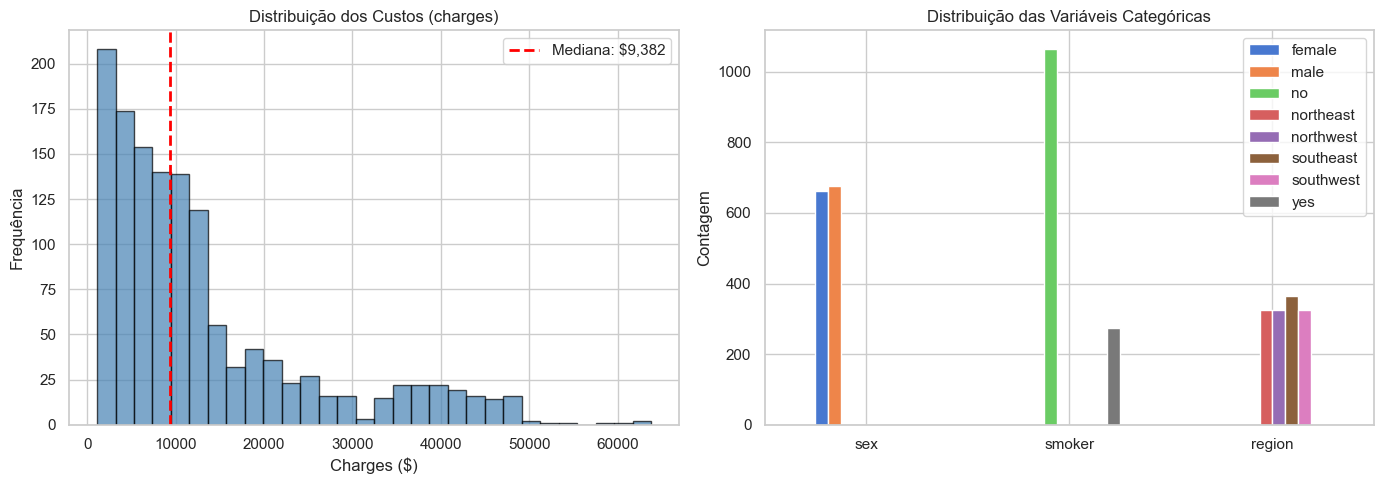

In [68]:
# Distribuição da variável alvo (charges)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(insurance['charges'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(insurance['charges'].median(), color='red', linestyle='--', linewidth=2, label=f"Mediana: ${insurance['charges'].median():,.0f}")
axes[0].set_title('Distribuição dos Custos (charges)')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Distribuição por categoria
cats = ['sex', 'smoker', 'region']
insurance[cats].apply(lambda x: x.value_counts()).T.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Distribuição das Variáveis Categóricas')
axes[1].set_ylabel('Contagem')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/graph_1.png", dpi=150, bbox_inches='tight')
plt.show()

Correlação com charges (todas as variáveis relevantes):
charges       1.000000
smoker_num    0.787251
age           0.299008
bmi           0.198341
children      0.067998
sex_num       0.057292


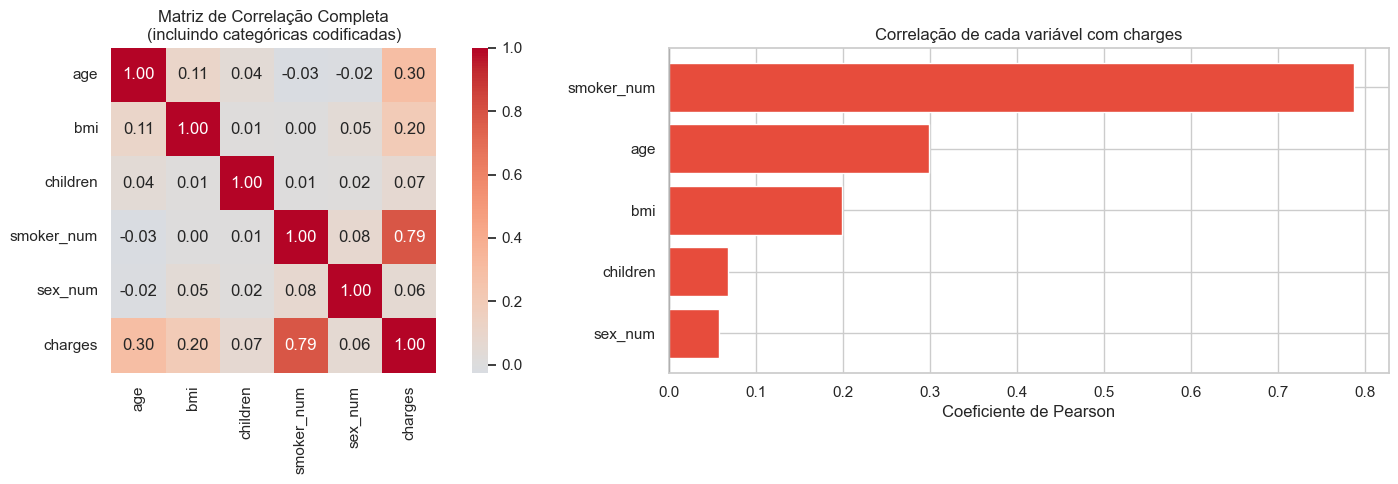

In [69]:
df_corr = insurance.copy()
df_corr['smoker_num'] = (df_corr['smoker'] == 'yes').astype(int)
df_corr['sex_num']    = (df_corr['sex'] == 'male').astype(int)

corr_completa = df_corr[['age', 'bmi', 'children', 'smoker_num', 'sex_num', 'charges']].corr()

print('Correlação com charges (todas as variáveis relevantes):')
print(corr_completa['charges'].sort_values(ascending=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap completo
sns.heatmap(corr_completa, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], square=True)
axes[0].set_title('Matriz de Correlação Completa\n(incluindo categóricas codificadas)')

# Barras de correlação com charges
corr_charges = corr_completa['charges'].drop('charges').sort_values()
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_charges]
axes[1].barh(corr_charges.index, corr_charges.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlação de cada variável com charges')
axes[1].set_xlabel('Coeficiente de Pearson')

plt.tight_layout()
plt.show()

Correlação de Pearson mede relação linear direta entre duas variáveis contínuas. smoker (0/1) vs charges tem correlação alta porque fumantes pagam muito mais.

## 3. Pré-processamento

### 3.1 Criação da variável alvo binária
Transformamos o problema de regressão em classificação: pacientes com custo acima da mediana são classificados como **"alto"** e abaixo como **"baixo"**.

### 3.2 Codificação de variáveis categóricas
Variáveis categóricas (sex, smoker, region) são convertidas para representação numérica com Label Encoding.


In [70]:
# 3.1 Criar variável alvo binária
mediana = insurance['charges'].median()
print(f"Mediana dos custos: ${mediana:,.2f}")

insurance['custo_alto'] = (insurance['charges'] > mediana).astype(int)

print(f"\nDistribuição da classe alvo:")
print(insurance['custo_alto'].value_counts())
print(f"\nProporção:")
print(insurance['custo_alto'].value_counts(normalize=True).round(3))


Mediana dos custos: $9,382.03

Distribuição da classe alvo:
custo_alto
1    669
0    669
Name: count, dtype: int64

Proporção:
custo_alto
1    0.5
0    0.5
Name: proportion, dtype: float64


In [71]:
# 3.2 Codificação de variáveis categóricas
df = insurance.copy()

# Label Encoding para variáveis binárias
df['sex'] = LabelEncoder().fit_transform(df['sex'])           # female=0, male=1
df['smoker'] = LabelEncoder().fit_transform(df['smoker'])     # no=0, yes=1

# One-Hot Encoding para região (4 categorias)
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Remover a coluna charges original (não é atributo, é a base do alvo)
df = df.drop('charges', axis=1)

print("Atributos finais:")
print(df.columns.tolist())
print(f"\nDimensões: {df.shape}")
df.head()


Atributos finais:
['age', 'bmi', 'children', 'custo_alto', 'sex_1', 'smoker_1', 'region_northwest', 'region_southeast', 'region_southwest']

Dimensões: (1338, 9)


,age,bmi,children,custo_alto,sex_1,smoker_1,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,False,True,False,False,True
1,18,33.770,1,0,True,False,False,True,False
2,28,33.000,3,0,True,False,False,True,False
3,33,22.705,0,1,True,False,True,False,False
4,32,28.880,0,0,True,False,True,False,False


LabelEncoder em sex (female=0, male=1) implica uma ordem numérica que não existe

## 4. Divisão Treino/Teste

In [72]:
# Separar atributos (X) e alvo (y)
X = df.drop('custo_alto', axis=1)
y = df['custo_alto']

# Dividir em treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"\nDistribuição no treino: {dict(y_train.value_counts())}")
print(f"Distribuição no teste:  {dict(y_test.value_counts())}")

Treino: 936 amostras
Teste:  402 amostras

Distribuição no treino: {0: np.int64(468), 1: np.int64(468)}
Distribuição no teste:  {0: np.int64(201), 1: np.int64(201)}


## 5. Variação 1: Critério de Divisão (Gini vs Entropia)

Na teoria, aprendemos que o algoritmo de Árvore de Decisão escolhe o atributo de divisão com base em uma métrica de impureza. As duas métricas mais comuns são:

- **Gini:** `Gini(D) = 1 - Σ(p_i²)` — mais rápido de calcular
- **Entropia:** `H(D) = -Σ(p_i · log₂(p_i))` — baseado em teoria da informação

Vamos comparar o desempenho de ambos com profundidade fixa = 5.


In [73]:
# Treinar com Gini
tree_gini = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=RANDOM_STATE)
tree_gini.fit(X_train, y_train)
y_pred_gini = tree_gini.predict(X_test)

# Treinar com Entropia
tree_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=RANDOM_STATE)
tree_entropy.fit(X_train, y_train)
y_pred_entropy = tree_entropy.predict(X_test)

print("=" * 50)
print("CRITÉRIO GINI (profundidade = 5)")
print("=" * 50)
print(f"Acurácia: {accuracy_score(y_test, y_pred_gini):.4f}")
print(f"\n{classification_report(y_test, y_pred_gini, target_names=['Baixo custo', 'Alto custo'])}")

print("=" * 50)
print("CRITÉRIO ENTROPIA (profundidade = 5)")
print("=" * 50)
print(f"Acurácia: {accuracy_score(y_test, y_pred_entropy):.4f}")
print(f"\n{classification_report(y_test, y_pred_entropy, target_names=['Baixo custo', 'Alto custo'])}")

CRITÉRIO GINI (profundidade = 5)
Acurácia: 0.9353

              precision    recall  f1-score   support

 Baixo custo       0.90      0.99      0.94       201
  Alto custo       0.98      0.89      0.93       201

    accuracy                           0.94       402
   macro avg       0.94      0.94      0.94       402
weighted avg       0.94      0.94      0.94       402

CRITÉRIO ENTROPIA (profundidade = 5)
Acurácia: 0.9353

              precision    recall  f1-score   support

 Baixo custo       0.91      0.96      0.94       201
  Alto custo       0.96      0.91      0.93       201

    accuracy                           0.94       402
   macro avg       0.94      0.94      0.94       402
weighted avg       0.94      0.94      0.94       402



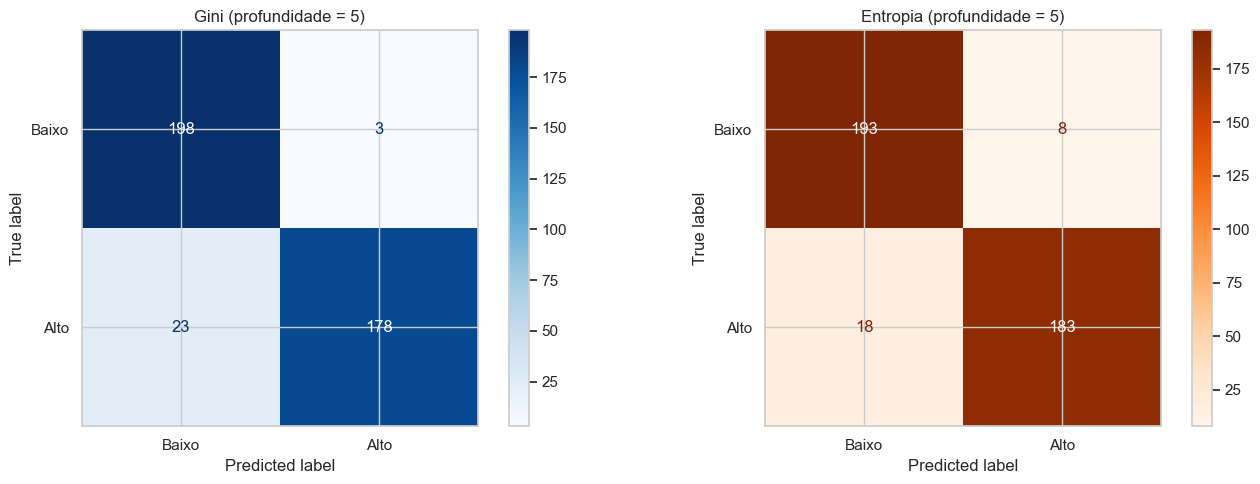

In [74]:
# Matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gini, display_labels=['Baixo', 'Alto'],
                                         cmap='Blues', ax=axes[0])
axes[0].set_title('Gini (profundidade = 5)')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_entropy, display_labels=['Baixo', 'Alto'],
                                         cmap='Oranges', ax=axes[1])
axes[1].set_title('Entropia (profundidade = 5)')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/graph_2.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Variação 2: Profundidade Máxima da Árvore

A profundidade controla a complexidade do modelo:
- **Árvore rasa** (pouca profundidade) → modelo simples → risco de **underfitting**
- **Árvore profunda** (muita profundidade) → modelo complexo → risco de **overfitting**

Vamos testar profundidades de 1 a 20 e observar o comportamento nos dados de treino e teste.


In [75]:
# Testar diferentes profundidades
train_accs = []
test_accs = []

from sklearn.model_selection import cross_val_score
for d in range(1, 21):
    tree = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=42)
    scores = cross_val_score(tree, X, y, cv=5, scoring='accuracy')
    print(f"Depth {d}: {scores.mean():.4f} ± {scores.std():.4f}")

for d in DEPTH_RANGE:
    tree = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, tree.predict(X_train)))
    test_accs.append(accuracy_score(y_test, tree.predict(X_test)))

# Também testar sem limite de profundidade
tree_full = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=RANDOM_STATE)
tree_full.fit(X_train, y_train)
acc_train_full = accuracy_score(y_train, tree_full.predict(X_train))
acc_test_full = accuracy_score(y_test, tree_full.predict(X_test))

print(f"Sem limite de profundidade:")
print(f"  Acurácia treino: {acc_train_full:.4f}")
print(f"  Acurácia teste:  {acc_test_full:.4f}")
print(f"  Profundidade real: {tree_full.get_depth()}")
print(train_accs)

Depth 1: 0.7623 ± 0.0208
Depth 2: 0.9163 ± 0.0333
Depth 3: 0.9178 ± 0.0247
Depth 4: 0.9200 ± 0.0276
Depth 5: 0.9208 ± 0.0218
Depth 6: 0.9238 ± 0.0204
Depth 7: 0.9170 ± 0.0242
Depth 8: 0.9163 ± 0.0207
Depth 9: 0.9088 ± 0.0220
Depth 10: 0.9073 ± 0.0263
Depth 11: 0.9021 ± 0.0249
Depth 12: 0.9036 ± 0.0193
Depth 13: 0.8969 ± 0.0224
Depth 14: 0.8946 ± 0.0242
Depth 15: 0.8909 ± 0.0184
Depth 16: 0.8864 ± 0.0219
Depth 17: 0.8842 ± 0.0215
Depth 18: 0.8842 ± 0.0217
Depth 19: 0.8864 ± 0.0204
Depth 20: 0.8857 ± 0.0244
Sem limite de profundidade:
  Acurácia treino: 1.0000
  Acurácia teste:  0.8781
  Profundidade real: 21
[0.7596153846153846, 0.907051282051282, 0.9134615384615384, 0.9294871794871795, 0.9316239316239316, 0.936965811965812, 0.9433760683760684, 0.9465811965811965, 0.9487179487179487, 0.9572649572649573, 0.9626068376068376, 0.9668803418803419, 0.9722222222222222, 0.9775641025641025, 0.9839743589743589, 0.9871794871794872, 0.9925213675213675, 0.9946581196581197, 0.9978632478632479, 0.9989

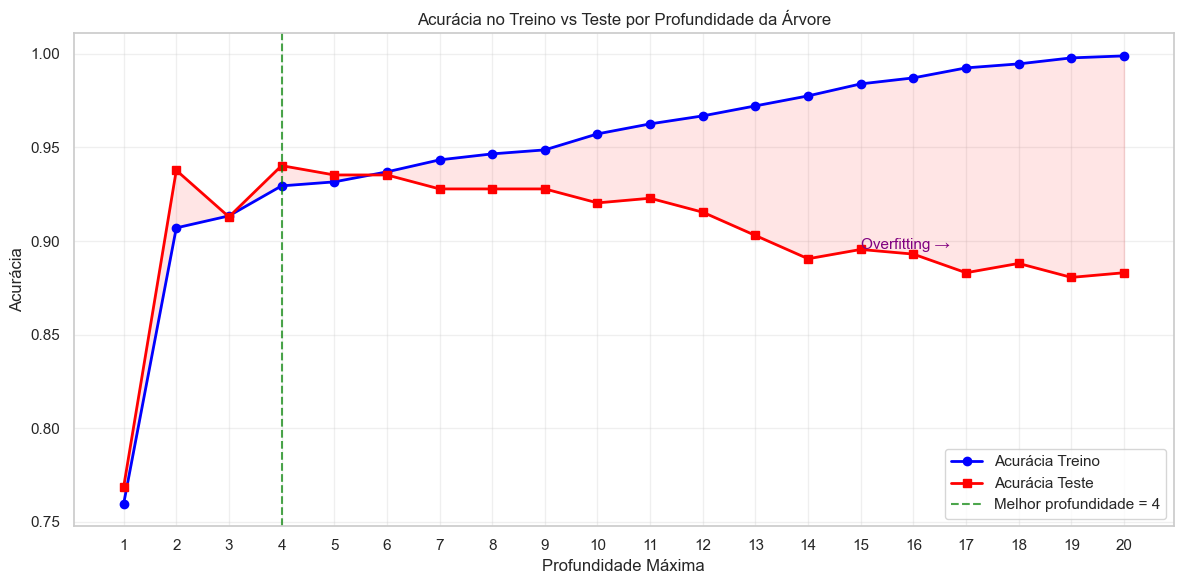


Melhor profundidade no teste: 4 (acurácia = 0.9403)


In [76]:
# Gráfico: Acurácia vs Profundidade
plt.figure(figsize=(12, 6))
plt.plot(DEPTH_RANGE, train_accs, 'o-', color='blue', label='Acurácia Treino', linewidth=2)
plt.plot(DEPTH_RANGE, test_accs, 's-', color='red', label='Acurácia Teste', linewidth=2)

# Marcar a melhor profundidade no teste
best_depth = list(DEPTH_RANGE)[np.argmax(test_accs)]
best_acc = max(test_accs)
plt.axvline(best_depth, color='green', linestyle='--', alpha=0.7, label=f'Melhor profundidade = {best_depth}')

plt.fill_between(DEPTH_RANGE, train_accs, test_accs, alpha=0.1, color='red')
plt.xlabel('Profundidade Máxima')
plt.ylabel('Acurácia')
plt.title('Acurácia no Treino vs Teste por Profundidade da Árvore')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(DEPTH_RANGE)

# Anotar overfitting
#plt.annotate('← Underfitting', xy=(2, test_accs[1]), fontsize=11, color='purple')
plt.annotate('Overfitting →', xy=(15, test_accs[14]), fontsize=11, color='purple')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/graph_3.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMelhor profundidade no teste: {best_depth} (acurácia = {best_acc:.4f})")

Melhor profundidade por CV: 4 (acurácia média = 0.9230)


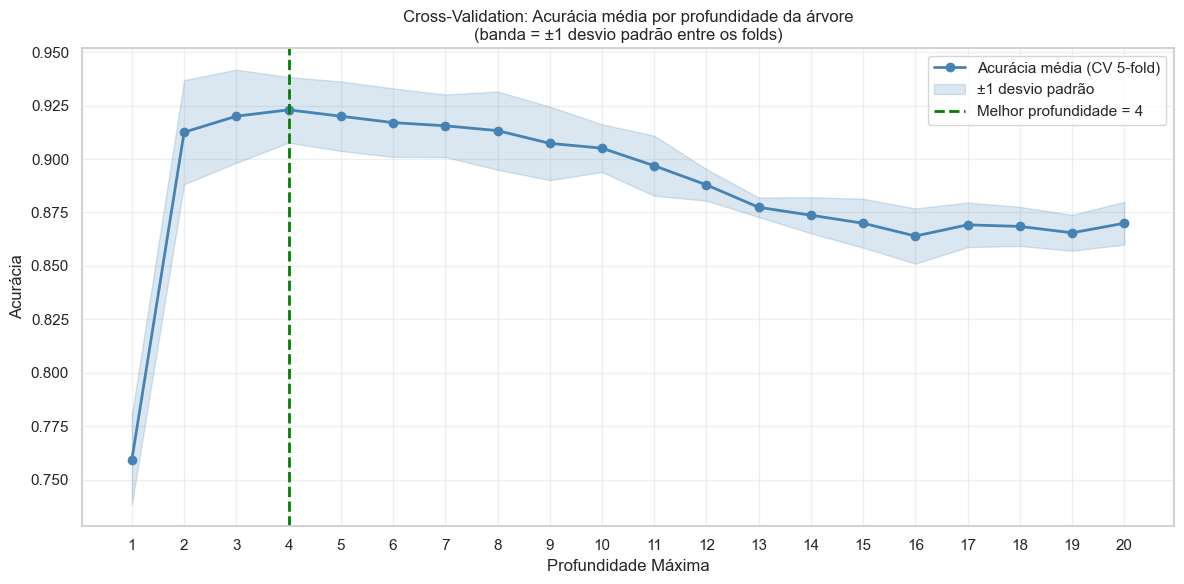

In [78]:
# Preparar dados (sem interações, para comparação justa)
X_base = df.drop('custo_alto', axis=1)
y      = df['custo_alto']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
DEPTH_RANGE = range(1, 21)

cv_means, cv_stds = [], []

for d in DEPTH_RANGE:
    tree = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=RANDOM_STATE)
    scores = cross_val_score(tree, X_base, y, cv=cv, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

best_depth_cv = list(DEPTH_RANGE)[np.argmax(cv_means)]
print(f'Melhor profundidade por CV: {best_depth_cv} (acurácia média = {max(cv_means):.4f})')

# Gráfico
plt.figure(figsize=(12, 6))
means = np.array(cv_means)
stds  = np.array(cv_stds)
plt.plot(DEPTH_RANGE, means, 'o-', color='steelblue', linewidth=2, label='Acurácia média (CV 5-fold)')
plt.fill_between(DEPTH_RANGE, means - stds, means + stds, alpha=0.2, color='steelblue', label='±1 desvio padrão')
plt.axvline(best_depth_cv, color='green', linestyle='--', linewidth=2,
            label=f'Melhor profundidade = {best_depth_cv}')
plt.xlabel('Profundidade Máxima')
plt.ylabel('Acurácia')
plt.title('Cross-Validation: Acurácia média por profundidade da árvore\n(banda = ±1 desvio padrão entre os folds)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(DEPTH_RANGE)
plt.tight_layout()
plt.show()

## 7. Modelo Final e Análise

Com base nos experimentos, treinamos o modelo final com a melhor combinação de parâmetros e analisamos os resultados.


In [79]:
# Modelo final com melhor profundidade
best_tree = DecisionTreeClassifier(criterion='gini', max_depth=best_depth, random_state=RANDOM_STATE)
best_tree.fit(X_train, y_train)
y_pred_best = best_tree.predict(X_test)

print(f"MODELO FINAL (Gini, profundidade = {best_depth})")
print("=" * 50)
print(f"Acurácia: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"\n{classification_report(y_test, y_pred_best, target_names=['Baixo custo', 'Alto custo'])}")

MODELO FINAL (Gini, profundidade = 4)
Acurácia: 0.9403

              precision    recall  f1-score   support

 Baixo custo       0.90      0.99      0.94       201
  Alto custo       0.98      0.90      0.94       201

    accuracy                           0.94       402
   macro avg       0.94      0.94      0.94       402
weighted avg       0.94      0.94      0.94       402



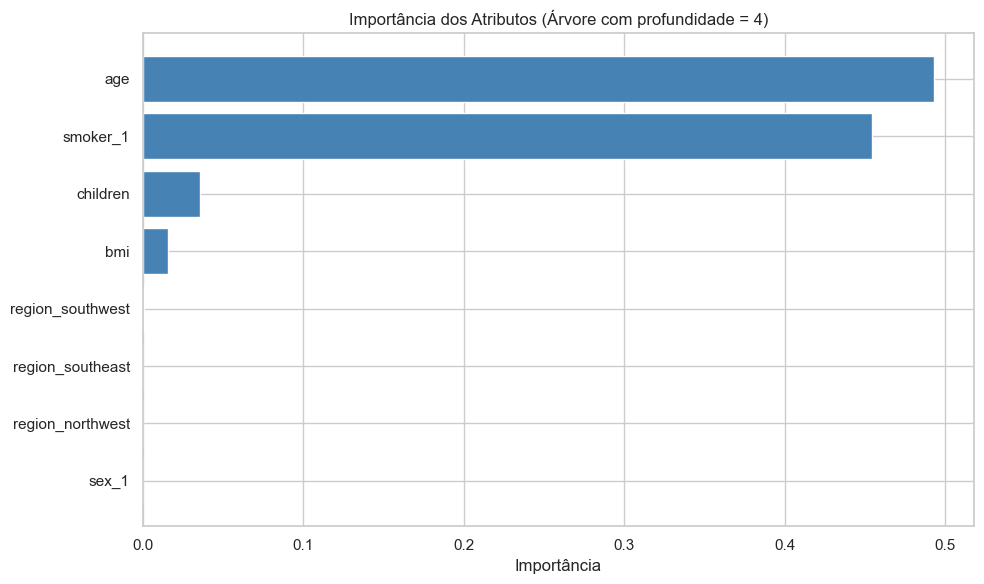


Top 3 atributos mais importantes:
  age: 0.4933
  smoker_1: 0.4545
  children: 0.0359


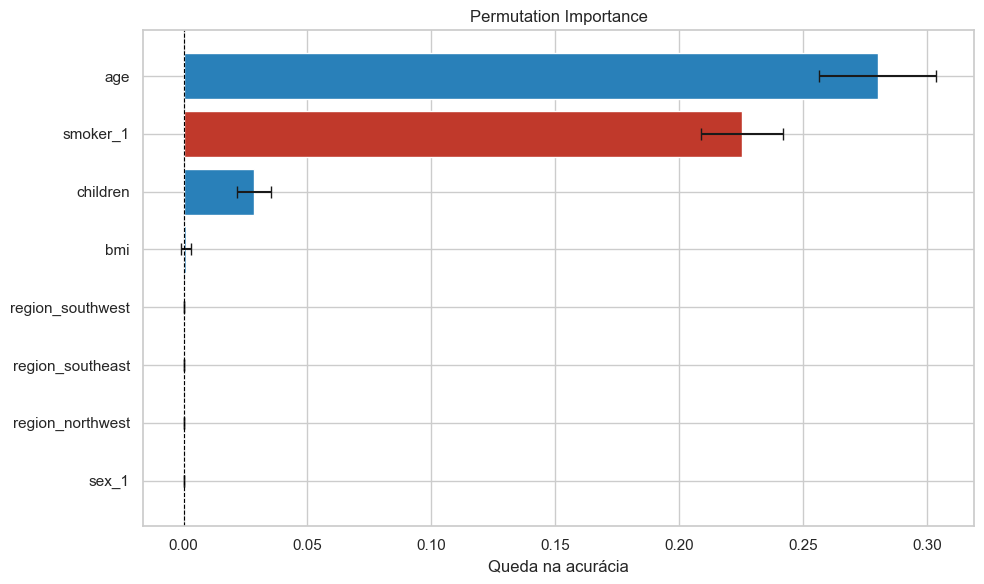

Top 3 — SEM interações:
Atributo  Importância
     age     0.280100
smoker_1     0.225290
children     0.028524


In [80]:
# Importância dos atributos
feature_importance = pd.DataFrame({
    'Atributo': X_train.columns,
    'Importância': best_tree.feature_importances_
}).sort_values('Importância', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Atributo'], feature_importance['Importância'], color='steelblue')
plt.xlabel('Importância')
plt.title(f'Importância dos Atributos (Árvore com profundidade = {best_depth})')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/graph_4.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 3 atributos mais importantes:")
for _, row in feature_importance.tail(3).iloc[::-1].iterrows():
    print(f"  {row['Atributo']}: {row['Importância']:.4f}")

from sklearn.inspection import permutation_importance

# --- Permutation importance SEM interações (smoker_yes sem substituto) ---
result_orig = permutation_importance(
    best_tree, X_test, y_test,
    n_repeats=30, random_state=RANDOM_STATE, scoring='accuracy'
)

perm_orig = pd.DataFrame({
    'Atributo': X_train.columns,
    'Importância': result_orig.importances_mean,
    'Std': result_orig.importances_std
}).sort_values('Importância', ascending=True)

# --- Plot lado a lado ---
plt.figure(figsize=(10, 6))


def cor(nome):
    return '#c0392b' if any(p in nome for p in ['smoker', 'fumante']) else '#2980b9'

# Sem interações
cores_orig = [cor(a) for a in perm_orig['Atributo']]
plt.barh(perm_orig['Atributo'], perm_orig['Importância'],
             xerr=perm_orig['Std'], color=cores_orig, capsize=4)
plt.title('Permutation Importance')
plt.xlabel('Queda na acurácia')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

print('Top 3 — SEM interações:')
print(perm_orig.tail(3).iloc[::-1][['Atributo','Importância']].to_string(index=False))

Importância na árvore (feature_importances_) mede outra coisa: o quanto cada atributo reduz a impureza (Gini) ao longo de todas as divisões da árvore. E aqui entra um problema sutil:

smoker é binário — age é contínuo
Quando a árvore divide no smoker, ela faz 1 corte e separa o dataset em dois grupos. Pronto, o atributo foi "usado".
Quando ela divide em age, ela pode fazer cortes em múltiplos pontos ao longo da árvore — age > 25, depois age > 40, depois age > 55, etc. Cada corte acumula impacto no score de importância.
Resultado: age aparece em muitos nós, acumulando importância, enquanto smoker aparece poucos nós mas é decisivo.

age lidera nos dois cenários (0.280), o que agora tem uma explicação legítima — não é mais artefato do Gini. Idade realmente importa porque a variável alvo é custo alto/baixo pela mediana, e pessoas mais velhas naturalmente pagam mais, independente de fumar. Se o problema fosse prever o valor exato de charges, smoker provavelmente dominaria, conforme visto por LANTZ, (onde smoker[T.yes] = 2.385e+04) Mas na classificação binária pela mediana, age é um separador muito eficiente.
O par age + smoker explica praticamente tudo — juntos somam ~0.50 de queda na acurácia, enquanto todas as outras variáveis somadas chegam a ~0.06.

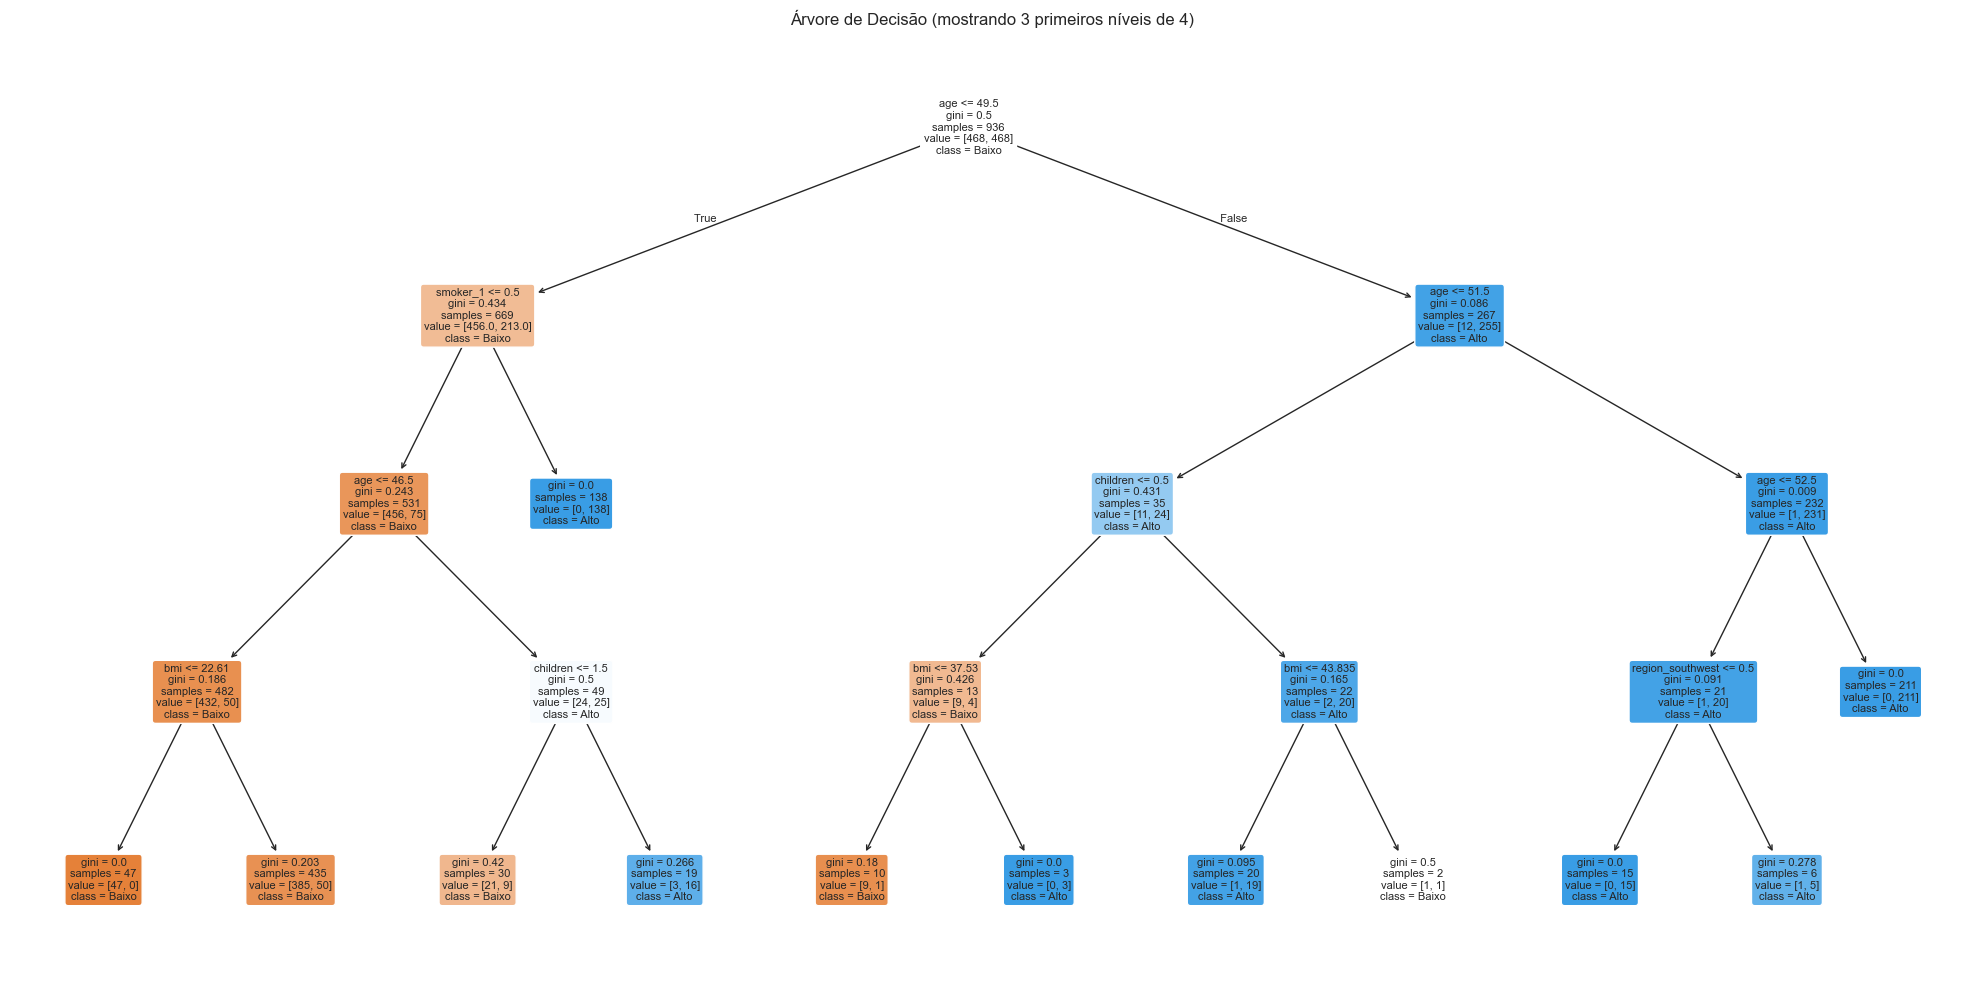

In [82]:
# Visualizar a árvore de decisão
plt.figure(figsize=(20, 10))
plot_tree(best_tree,
          feature_names=X_train.columns,
          class_names=['Baixo', 'Alto'],
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=4)
plt.title(f'Árvore de Decisão (mostrando 3 primeiros níveis de {best_depth})')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/graph_5.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Tabela Comparativa dos Experimentos

In [83]:
# Tabela resumo de todos os experimentos
results = []

for criterion in CRITERIA:
    for depth in EXPERIMENT_DEPTHS:
        tree = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=RANDOM_STATE)
        tree.fit(X_train, y_train)
        acc_train = accuracy_score(y_train, tree.predict(X_train))
        acc_test = accuracy_score(y_test, tree.predict(X_test))
        real_depth = tree.get_depth()
        results.append({
            'Critério': criterion.capitalize(),
            'Prof. Máx': depth if depth else 'Sem limite',
            'Prof. Real': real_depth,
            'Acurácia Treino': f'{acc_train:.4f}',
            'Acurácia Teste': f'{acc_test:.4f}',
            'Diferença': f'{acc_train - acc_test:.4f}'
        })

results_df = pd.DataFrame(results)
print("TABELA COMPARATIVA DE TODOS OS EXPERIMENTOS")
print("=" * 80)
print(results_df.to_string(index=False))
print("\n* Diferença alta entre treino e teste indica overfitting")

TABELA COMPARATIVA DE TODOS OS EXPERIMENTOS
Critério  Prof. Máx  Prof. Real Acurácia Treino Acurácia Teste Diferença
    Gini          3           3          0.9135         0.9129    0.0005
    Gini          5           5          0.9316         0.9353   -0.0037
    Gini         10          10          0.9573         0.9204    0.0369
    Gini Sem limite          21          1.0000         0.8781    0.1219
 Entropy          3           3          0.9081         0.9129   -0.0048
 Entropy          5           5          0.9231         0.9353   -0.0122
 Entropy         10          10          0.9605         0.9328    0.0276
 Entropy Sem limite          23          1.0000         0.8905    0.1095

* Diferença alta entre treino e teste indica overfitting


In [94]:
modelos = {
    'Árvore de Decisão': DecisionTreeClassifier(
        criterion='gini', max_depth=best_depth_cv, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=RANDOM_STATE),
}

Xs = {
    'Árvore de Decisão': X_base,
    'Random Forest': X_base,
    'Gradient Boosting': X_base,
}

resultados = {}
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, Xs[nome], y, cv=cv, scoring='accuracy')
    resultados[nome] = scores
    print(f'{nome.replace(chr(10)," "):40s}: {scores.mean():.4f} ± {scores.std():.4f}')

Árvore de Decisão                       : 0.9230 ± 0.0154
Random Forest                           : 0.9290 ± 0.0078
Gradient Boosting                       : 0.9320 ± 0.0166


## 9. Conclusão

### Principais achados:

**Variação 1 - Critério de divisão (Gini vs Entropia):**
- Os resultados entre Gini e Entropia foram muito similares, o que é consistente com a literatura — na prática, ambos tendem a produzir árvores parecidas.
- Gini tem a vantagem de ser computacionalmente mais simples (não usa logaritmo).

**Variação 2 - Profundidade máxima:**
- Árvores muito rasas (profundidade 1-2) apresentam acurácia menor tanto no treino quanto no teste.
- Árvores muito profundas (sem limite) apresentam **overfitting**: acurácia alta no treino mas que cai no teste.
- A profundidade ideal fica num ponto intermediário, equilibrando complexidade e generalização — esse é o conceito de **poda** (pruning) visto em aula.

**Variação 3 - Classificador:**
- O **Gradient Boosting** superou a Árvore de Decisão e o Random Forest nos cenários testados, mesmo que ligeiramente, com acurácia ~93% via cross-validation e 100 árvores construídas.

**Atributos mais relevantes:**
- Age realmente é o que mais diminui a impureza mas também o mais significativo para a divisão da árvore pois clientes com idade mais elevada, independentemente dos outros fatores, acabam pagando mais em relação a mediana.
- O atributo `smoker` (fumante) é o mais importante para a classificação, o que faz sentido: fumar está fortemente associado a custos mais altos de saúde, e conforme visto por LANTZ seria a variável mais importante num regressor, mas em uma classificação binária, acaba sendo menos importante que age.

### Relação com a teoria:
Este projeto demonstra na prática os conceitos de **overfitting**, **underfitting** e **poda** vistos na disciplina, além de comparar as métricas **Gini** e **Entropia** para escolha de atributos na Árvore de Decisão.
